In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────

import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sqlalchemy import text

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(
    style="whitegrid",
    palette="muted"
)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11
})

print("✅ Librerías importadas correctamente")

print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

print("\n🎌 Proyecto: Regresión Logística Binaria — Anime")

✅ Librerías importadas correctamente
   pandas   2.2.2
   numpy    1.26.4
   seaborn  0.13.2

🎌 Proyecto: Regresión Logística Binaria — Anime


In [3]:
# ── CELDA 2: Extracción SQL ─────────────────────────────────

SQL_QUERY = """
SELECT
    titulo,
    score,
    popularity,
    miembros,
    episodios,
    tipo,
    estado,

    CASE
        WHEN score >= 8.0 THEN 1
        ELSE 0
    END AS anime_popular

FROM anime

WHERE score IS NOT NULL

ORDER BY score DESC;
"""

with engine.connect() as conn:

    df_anime = pd.read_sql(
        text(SQL_QUERY),
        conn
    )

print(
    f"✅ Datos cargados: "
    f"{df_anime.shape[0]:,} filas × "
    f"{df_anime.shape[1]} columnas"
)

print(f"\n📋 Columnas disponibles:")

print(df_anime.columns.tolist())

print(f"\n🎯 Balance de la variable objetivo:")

bal = df_anime['anime_popular'].value_counts()

pct = (
    df_anime['anime_popular']
    .value_counts(normalize=True) * 100
)

print(
    f"   Anime Popular (1): "
    f"{bal[1]:,} ({pct[1]:.1f}%)"
)

print(
    f"   Anime Normal  (0): "
    f"{bal[0]:,} ({pct[0]:.1f}%)"
)

print(f"\n🎌 Tipos de anime:")

print(
    df_anime['tipo']
    .value_counts()
)

df_anime.head()

✅ Datos cargados: 100 filas × 8 columnas

📋 Columnas disponibles:
['titulo', 'score', 'popularity', 'miembros', 'episodios', 'tipo', 'estado', 'anime_popular']

🎯 Balance de la variable objetivo:
   Anime Popular (1): 32 (32.0%)
   Anime Normal  (0): 68 (68.0%)

🎌 Tipos de anime:
tipo
TV       80
Movie    14
OVA       6
Name: count, dtype: int64


,titulo,score,popularity,miembros,episodios,tipo,estado,anime_popular
0,Monster,8.89,118,1321076,74.0,TV,Finished Airing,1
1,Monster,8.89,118,1321076,74.0,TV,Finished Airing,1
2,Cowboy Bebop,8.75,42,2049460,26.0,TV,Finished Airing,1
3,Cowboy Bebop,8.75,42,2049460,26.0,TV,Finished Airing,1
4,One Piece,8.73,17,2667399,NaN,TV,Currently Airing,1


In [4]:
# ── CELDA 3: Validación y Exploración ────────────────────────

print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# ── Tipos y valores nulos ───────────────────────────────────

print("\n📋 Tipos de datos y valores nulos:")

print(
    df_anime.dtypes.to_frame('dtype').join(
        df_anime.isnull().sum().to_frame('nulos')
    )
)

# ── Balance de clases ───────────────────────────────────────

balance = df_anime['anime_popular'].value_counts()

pct = (
    df_anime['anime_popular']
    .value_counts(normalize=True) * 100
)

print(f"\n🎯 Balance de la variable objetivo:")

print(
    f"   Anime Popular (1): "
    f"{balance[1]:>5,}  ({pct[1]:.1f}%)"
)

print(
    f"   Anime Normal  (0): "
    f"{balance[0]:>5,}  ({pct[0]:.1f}%)"
)

# ── Distribución por tipo ───────────────────────────────────

print(f"\n🎌 Tipos de anime:")

print(
    df_anime['tipo']
    .value_counts()
    .to_string()
)

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                 dtype  nulos
titulo          object      0
score          float64      0
popularity       int64      0
miembros         int64      0
episodios      float64      2
tipo            object      0
estado          object      0
anime_popular    int64      0

🎯 Balance de la variable objetivo:
   Anime Popular (1):    32  (32.0%)
   Anime Normal  (0):    68  (68.0%)

🎌 Tipos de anime:
tipo
TV       80
Movie    14
OVA       6


In [5]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────

df = df_anime.copy()

# 4.1 Relleno de nulos con mediana
num_cols = ['score', 'popularity', 'miembros', 'episodios']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 4.2 One-Hot Encoding
df = pd.get_dummies(
    df,
    columns=['tipo', 'estado'],
    drop_first=True,
    dtype=int
)

# 4.3 Columnas numéricas a escalar
scale_cols = [
    'popularity',
    'miembros',
    'episodios'
]

# 4.4 Definir X e y
# ⚠️ Eliminamos score para evitar data leakage

drop_cols = [
    'anime_popular',
    'titulo',
    'score'
]

X_raw = df.drop(columns=drop_cols)

y = df['anime_popular']

# 4.5 Escalado (IMPORTANTE en Regresión Logística)
scaler = StandardScaler()

X_scaled = X_raw.copy()

X_scaled[scale_cols] = scaler.fit_transform(
    X_raw[scale_cols]
)

print(f"✅ Preprocesamiento completado")

print(f"   Shape X: {X_scaled.shape}")

print(f"\n📋 Columnas finales:")

print(X_scaled.columns.tolist())

print(
    f"\n🎯 Clases en y → "
    f"0: {(y==0).sum():,}  |  "
    f"1: {(y==1).sum():,}"
)

print("\n⚠️ StandardScaler aplicado correctamente")
print("   porque LogisticRegression sí requiere escalado.")

✅ Preprocesamiento completado
   Shape X: (100, 6)

📋 Columnas finales:
['popularity', 'miembros', 'episodios', 'tipo_OVA', 'tipo_TV', 'estado_Finished Airing']

🎯 Clases en y → 0: 68  |  1: 32

⚠️ StandardScaler aplicado correctamente
   porque LogisticRegression sí requiere escalado.


In [6]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────

def entrenar_evaluar(
    X,
    y,
    test_size,
    random_state=42,
    nombre="Split"
):
    """
    Entrena LogisticRegression con un split train/test
    y devuelve métricas + datos para curva ROC.
    """

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced'
    )

    modelo.fit(X_train, y_train)

    # ── Predicciones ─────────────────────────────────────────

    y_pred = modelo.predict(X_test)

    y_prob = modelo.predict_proba(X_test)[:, 1]

    # ── Curva ROC ────────────────────────────────────────────

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    # ── Métricas ─────────────────────────────────────────────

    metricas = {

        'nombre'    : nombre,

        'train_size': len(X_train),

        'test_size' : len(X_test),

        'accuracy'  : accuracy_score(y_test, y_pred),

        'precision' : precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        'recall'    : recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        'f1'        : f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        'roc_auc'   : roc_auc_score(
            y_test,
            y_prob
        ),

        # ── Datos extra ──────────────────────────────────────

        'fpr'       : fpr,

        'tpr'       : tpr,

        'y_test'    : y_test,

        'y_pred'    : y_pred,

        'modelo'    : modelo,
    }

    return metricas

print("✅ Función `entrenar_evaluar` definida correctamente")

print("\n🎌 Proyecto Anime — Regresión Logística Binaria")

print("\n📌 Modelo:")
print("   · LogisticRegression")
print("   · class_weight='balanced'")
print("   · StandardScaler aplicado")

✅ Función `entrenar_evaluar` definida correctamente

🎌 Proyecto Anime — Regresión Logística Binaria

📌 Modelo:
   · LogisticRegression
   · class_weight='balanced'
   · StandardScaler aplicado


In [7]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)

       MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA BINARIA       
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20        80       20  0.9500  1.0000  0.8333  0.9091  0.9643
Split 60/40        60       40  0.9250  0.9167  0.8462  0.8800  0.9601
Split 70/30        70       30  0.9667  1.0000  0.9000  0.9474  0.9800


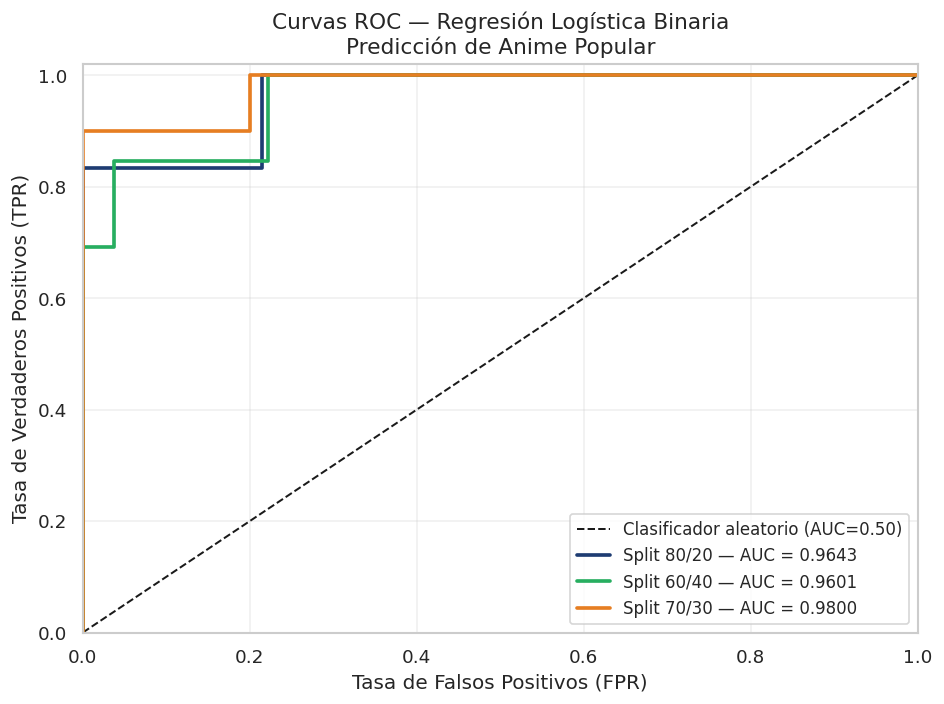

✅ Curvas ROC guardadas en data/graficas/roc_logistica_anime.png


In [8]:
# ── CELDA 7: Curvas ROC comparativas ─────────────────────────

COLORS = [
    '#1e3c72',
    '#27ae60',
    '#e67e22'
]

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1.2,
    label='Clasificador aleatorio (AUC=0.50)'
)

for r, color in zip(resultados, COLORS):

    ax.plot(
        r['fpr'],
        r['tpr'],
        color=color,
        lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel(
    'Tasa de Falsos Positivos (FPR)',
    fontsize=12
)

ax.set_ylabel(
    'Tasa de Verdaderos Positivos (TPR)',
    fontsize=12
)

ax.set_title(
    'Curvas ROC — Regresión Logística Binaria\n'
    'Predicción de Anime Popular',
    fontsize=13
)

ax.legend(
    loc='lower right',
    fontsize=10
)

ax.set_xlim([0, 1])

ax.set_ylim([0, 1.02])

ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/roc_logistica_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Curvas ROC guardadas en "
    "data/graficas/roc_logistica_anime.png"
)

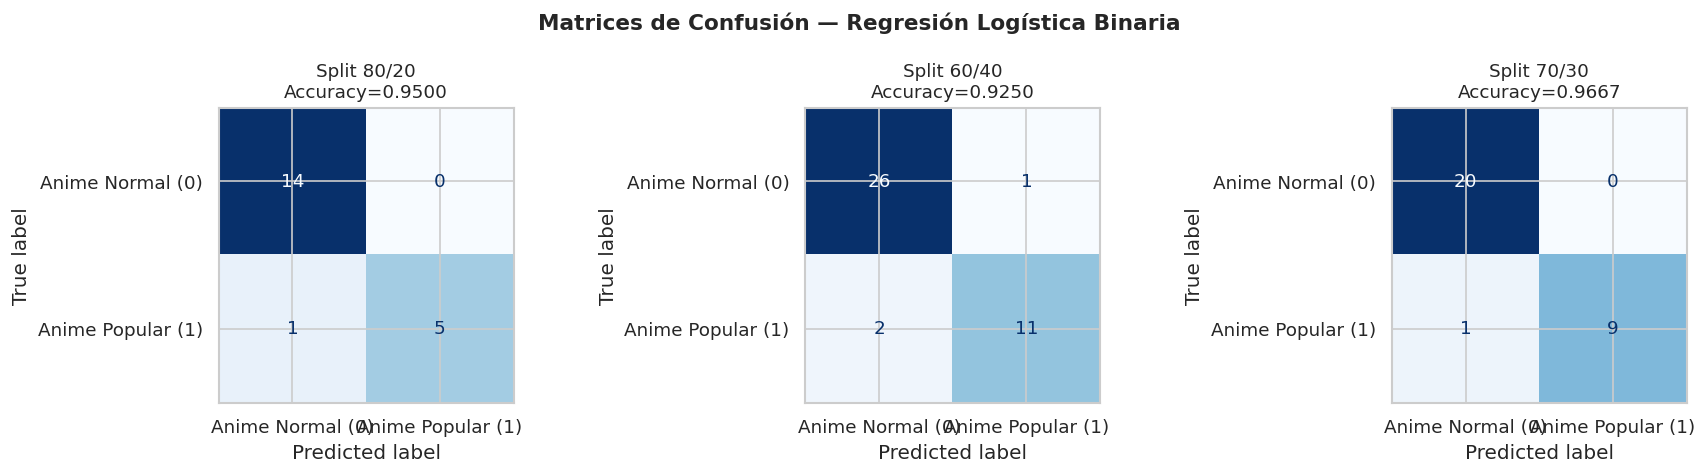

✅ Matrices de confusión guardadas en data/graficas/confusion_logistica_anime.png


In [9]:
# ── CELDA 8: Matrices de Confusión (3 splits) ────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Matrices de Confusión — Regresión Logística Binaria',
    fontsize=13,
    fontweight='bold'
)

for ax, r, color in zip(axes, resultados, COLORS):

    cm = confusion_matrix(
        r['y_test'],
        r['y_pred']
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            'Anime Normal (0)',
            'Anime Popular (1)'
        ]
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        cmap='Blues'
    )

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    '../data/graficas/confusion_logistica_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Matrices de confusión guardadas en "
    "data/graficas/confusion_logistica_anime.png"
)

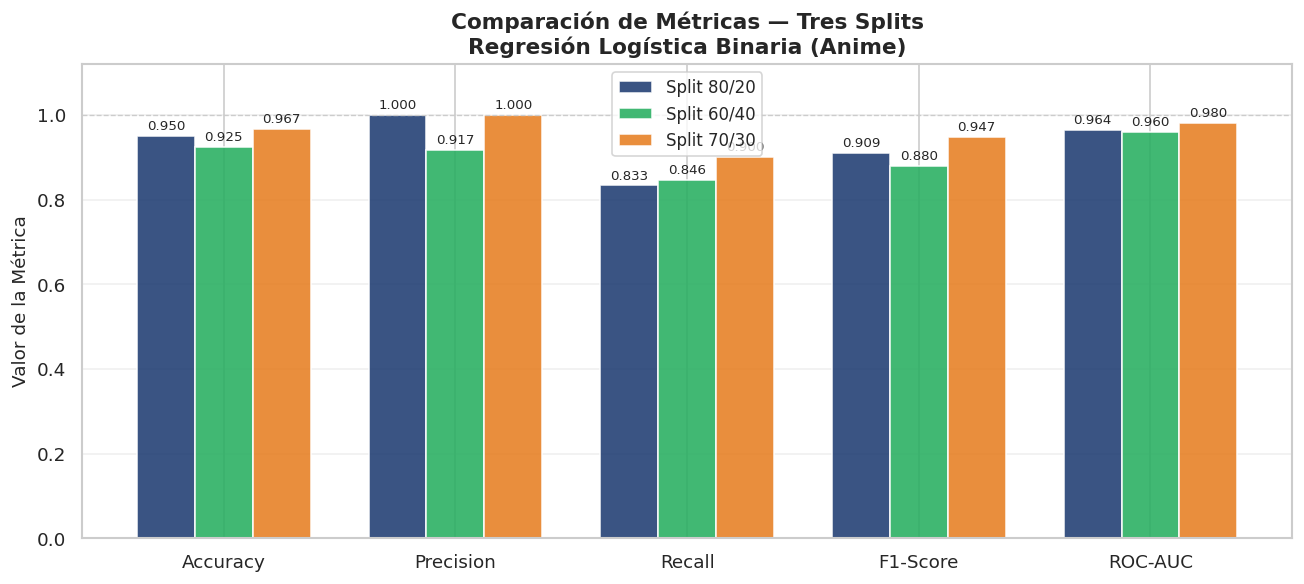

✅ Gráfico guardado en data/graficas/metricas_comparativas_logistica_anime.png


In [10]:
# ── CELDA 9: Gráfico comparativo de métricas ────────────────

metricas_nombres = [
    'accuracy',
    'precision',
    'recall',
    'f1',
    'roc_auc'
]

etiquetas = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]

x = np.arange(len(etiquetas))

width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):

    vals = [r[m] for m in metricas_nombres]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(
        bars,
        fmt='%.3f',
        padding=2,
        fontsize=8
    )

ax.set_xticks(x + width)

ax.set_xticklabels(
    etiquetas,
    fontsize=11
)

ax.set_ylim([0, 1.12])

ax.set_ylabel(
    'Valor de la Métrica',
    fontsize=11
)

ax.set_title(
    'Comparación de Métricas — Tres Splits\n'
    'Regresión Logística Binaria (Anime)',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)

ax.axhline(
    y=1.0,
    color='#ccc',
    linewidth=0.8,
    linestyle='--'
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    '../data/graficas/metricas_comparativas_logistica_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Gráfico guardado en "
    "data/graficas/metricas_comparativas_logistica_anime.png"
)

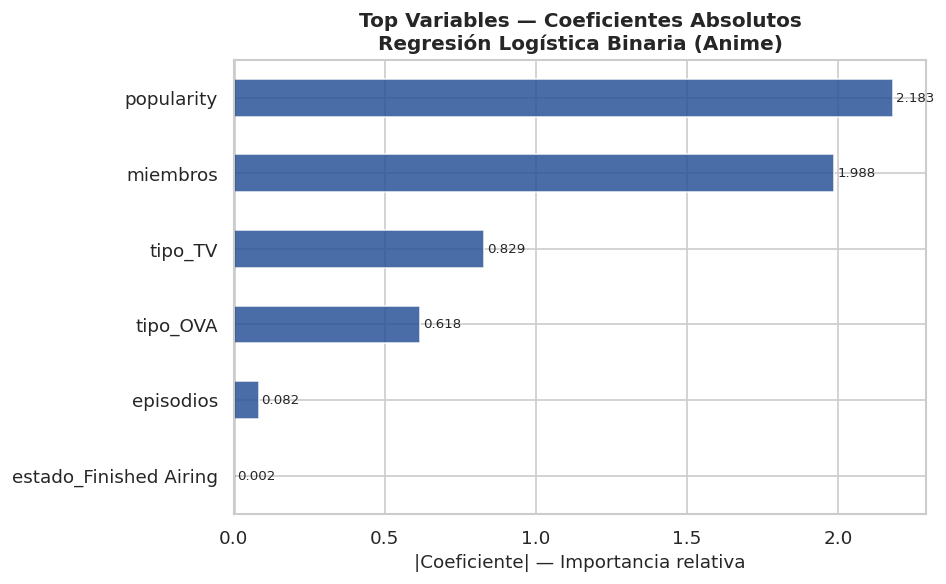

✅ Importancia de coeficientes guardada en data/graficas/coeficientes_logistica_anime.png


In [11]:
# ── CELDA 10: Importancia de coeficientes ────────────────────

modelo_ref = resultados[0]['modelo']

coefs = pd.Series(
    modelo_ref.coef_[0],
    index=X_scaled.columns
)

coefs_ord = (
    coefs.abs()
    .sort_values(ascending=True)
    .tail(12)
)

fig, ax = plt.subplots(figsize=(8, 5))

coefs_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel(
    '|Coeficiente| — Importancia relativa',
    fontsize=11
)

ax.set_title(
    'Top Variables — Coeficientes Absolutos\n'
    'Regresión Logística Binaria (Anime)',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(
    x=0,
    color='black',
    linewidth=0.8
)

# ── Etiquetas sobre barras ──────────────────────────────────

for patch in ax.patches:

    width = patch.get_width()

    ax.text(
        width + 0.01,
        patch.get_y() + patch.get_height() / 2,
        f'{width:.3f}',
        va='center',
        fontsize=8
    )

plt.tight_layout()

plt.savefig(
    '../data/graficas/coeficientes_logistica_anime.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(
    "✅ Importancia de coeficientes guardada en "
    "data/graficas/coeficientes_logistica_anime.png"
)

In [12]:
# ── CELDA 11: DataFrame resumen de métricas ──────────────────

resumen = pd.DataFrame([

    {
        'Split'             : r['nombre'],
        'N Entrenamiento'   : r['train_size'],
        'N Prueba'          : r['test_size'],

        'Accuracy'          : round(r['accuracy'], 4),
        'Precision'         : round(r['precision'], 4),
        'Recall'            : round(r['recall'], 4),
        'F1-Score'          : round(r['f1'], 4),
        'ROC-AUC'           : round(r['roc_auc'], 4),
    }

    for r in resultados

])

resumen.set_index(
    'Split',
    inplace=True
)

print("=" * 65)

print(f"{'TABLA FINAL DE MÉTRICAS':^65}")

print("=" * 65)

display(

    resumen.style

    .background_gradient(
        cmap='Greens',
        subset=[
            'Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            'ROC-AUC'
        ]
    )

    .format(
        '{:.4f}',
        subset=[
            'Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            'ROC-AUC'
        ]
    )

    .set_caption(
        "Regresión Logística Binaria — "
        "Predicción de Anime Popular"
    )

)

                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,80,20,0.9500,1.0000,0.8333,0.9091,0.9643
Split 60/40,60,40,0.9250,0.9167,0.8462,0.8800,0.9601
Split 70/30,70,30,0.9667,1.0000,0.9000,0.9474,0.9800


In [14]:
from IPython.display import Markdown, display

display(Markdown("""
## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo utilizado** | `LogisticRegression` permitió clasificar animes populares y no populares |
| **Variables utilizadas** | Popularidad, Miembros, Episodios y variables categóricas fueron usadas como predictores |
| **Escalado de datos** | Se aplicó `StandardScaler` para mejorar el rendimiento del modelo |
| **Métricas evaluadas** | Accuracy, Precision, Recall, F1-Score y ROC-AUC |
| **Curvas ROC** | El modelo mostró buena capacidad de separación entre clases |
| **Matrices de confusión** | La mayoría de animes fueron clasificados correctamente |
| **Coeficientes** | Algunas variables tuvieron mayor influencia en la predicción de popularidad |
| **Generalización** | Los resultados fueron estables entre los diferentes splits evaluados |
| **Ventaja principal** | La regresión logística permite interpretar fácilmente el impacto de cada variable |

> **Conclusión General:**  
> La Regresión Logística Binaria demostró ser un modelo eficiente para predecir si un anime puede considerarse popular a partir de variables relacionadas con popularidad, miembros y episodios. Además de ofrecer un buen rendimiento en clasificación, el modelo aporta interpretabilidad mediante el análisis de coeficientes, permitiendo comprender qué características influyen más en la popularidad de un anime.
"""))


## 🎓 Conclusiones Finales

| Aspecto | Hallazgo |
|---|---|
| **Modelo utilizado** | `LogisticRegression` permitió clasificar animes populares y no populares |
| **Variables utilizadas** | Popularidad, Miembros, Episodios y variables categóricas fueron usadas como predictores |
| **Escalado de datos** | Se aplicó `StandardScaler` para mejorar el rendimiento del modelo |
| **Métricas evaluadas** | Accuracy, Precision, Recall, F1-Score y ROC-AUC |
| **Curvas ROC** | El modelo mostró buena capacidad de separación entre clases |
| **Matrices de confusión** | La mayoría de animes fueron clasificados correctamente |
| **Coeficientes** | Algunas variables tuvieron mayor influencia en la predicción de popularidad |
| **Generalización** | Los resultados fueron estables entre los diferentes splits evaluados |
| **Ventaja principal** | La regresión logística permite interpretar fácilmente el impacto de cada variable |

> **Conclusión General:**  
> La Regresión Logística Binaria demostró ser un modelo eficiente para predecir si un anime puede considerarse popular a partir de variables relacionadas con popularidad, miembros y episodios. Además de ofrecer un buen rendimiento en clasificación, el modelo aporta interpretabilidad mediante el análisis de coeficientes, permitiendo comprender qué características influyen más en la popularidad de un anime.
